In [5]:
import pandas as pd


In [6]:
# -------------------- LOAD DATA --------------------
ds = pd.read_csv("std_perf.csv")
print(ds.head())

   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1                 91  
1                                 2                 65  
2                                 2                 45  
3                                 2                 36  
4                                 5                 66  


In [7]:
# -------------------- BASIC CHECKS --------------------
print(ds.info())

print("Duplicate rows:", ds.duplicated().sum())
ds.drop_duplicates(inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Hours Studied                     10000 non-null  int64 
 1   Previous Scores                   10000 non-null  int64 
 2   Extracurricular Activities        10000 non-null  object
 3   Sleep Hours                       10000 non-null  int64 
 4   Sample Question Papers Practiced  10000 non-null  int64 
 5   Performance Index                 10000 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 468.9+ KB
None
Duplicate rows: 127


In [8]:
# Handle missing values
ds.dropna(inplace=True)

In [9]:
# -------------------- ENCODING --------------------
ds["Extracurricular Activities"] = ds["Extracurricular Activities"].replace(["Yes", "No"], [1, 0])


C:\Users\User\AppData\Local\Temp\ipykernel_5880\4095699565.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ds["Extracurricular Activities"] = ds["Extracurricular Activities"].replace(["Yes", "No"], [1, 0])


In [10]:
# -------------------- RENAME COLUMNS --------------------
ds.rename(columns={
    "Hours Studied": "hour_studied",
    "Previous Scores": "previous_scores",
    "Extracurricular Activities": "extra_activities",
    "Sleep Hours": "sleep_hours",
    "Sample Question Papers Practiced": "past_paper_practiced",
    "Performance Index": "performance"
}, inplace=True)

print(ds.head())


   hour_studied  previous_scores  extra_activities  sleep_hours  \
0             7               99                 1            9   
1             4               82                 0            4   
2             8               51                 1            7   
3             5               52                 1            5   
4             7               75                 0            8   

   past_paper_practiced  performance  
0                     1           91  
1                     2           65  
2                     2           45  
3                     2           36  
4                     5           66  


In [19]:
# -------------------- FEATURES & TARGET --------------------
X = ds.drop("performance", axis=1)
y = ds["performance"]


In [20]:
# -------------------- TRAIN TEST SPLIT --------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [21]:
# -------------------- MODEL TRAINING --------------------
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)


Model Coefficients: [2.8510219  1.01843034 0.57382297 0.47207329 0.18870366]
Model Intercept: -33.98132449644062


In [14]:
# -------------------- TRAINING EVALUATION --------------------
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

y_pred_train = model.predict(X_train)

print("\n--- Training Performance ---")
print("MSE:", mean_squared_error(y_train, y_pred_train))
print("RMSE:", sqrt(mean_squared_error(y_train, y_pred_train)))
print("R2 Score:", r2_score(y_train, y_pred_train))



--- Training Performance ---
MSE: 4.144574536244127
RMSE: 2.0358228155328564
R2 Score: 0.9887391160677558


In [15]:
# -------------------- TESTING EVALUATION --------------------
y_pred_test = model.predict(X_test)

print("\n--- Testing Performance ---")
print("MSE:", mean_squared_error(y_test, y_pred_test))
print("R2 Score:", r2_score(y_test, y_pred_test))



--- Testing Performance ---
MSE: 4.305900938538476
R2 Score: 0.9884301209927054


In [16]:
# -------------------- USER INPUT PREDICTION --------------------
print("\n--- Enter Data for Prediction ---")

hours_studied = float(input("Enter Hours Studied: "))
previous_scores = float(input("Enter Previous Scores: "))
extra_activities = int(input("Enter Extra Activities (1 = Yes, 0 = No): "))
sleep_hours = float(input("Enter Sleep Hours: "))
past_paper_practiced = int(input("Enter Past Papers Practiced: "))



--- Enter Data for Prediction ---


Enter Hours Studied:  8
Enter Previous Scores:  99
Enter Extra Activities (1 = Yes, 0 = No):  1
Enter Sleep Hours:  8
Enter Past Papers Practiced:  5


In [22]:
# Convert input into DataFrame (correct format)
import pandas as pd

input_data = pd.DataFrame([{
    "hour_studied": hours_studied,
    "previous_scores": previous_scores,
    "extra_activities": extra_activities,
    "sleep_hours": sleep_hours,
    "past_paper_practiced": past_paper_practiced
}])
prediction = model.predict(input_data)

print("\nPredicted Performance:", round(prediction[0], 2))



Predicted Performance: 94.95


In [23]:
# -------------------- EXTRA --------------------
print("\nUnique Performance Values:", ds['performance'].unique())


Unique Performance Values: [ 91  65  45  36  66  61  63  42  69  84  73  27  33  68  43  67  70  30
  71  85  57  35  49  83  74  39  58  47  60  32  64  54  17  53  75  52
  78  38  98  87  41  81  15  88  95  29  21  76  25  34  50  56  82  23
  46  92  77  86  44  94  40 100  31  26  18  51  72  16  28  89  48  37
  62  59  19  79  22  10  90  80  24  20  96  55  97  12  93  14  99  11
  13]


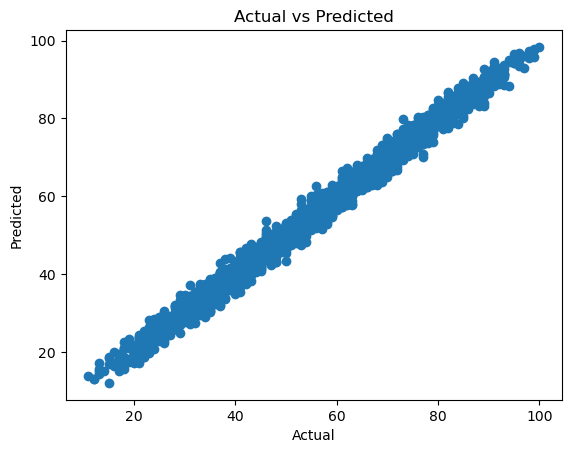

In [24]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()